# The Intender Gap — Predictive Modeling
## `03_modeling.ipynb`

---

### Business Question

**Among developers who are not currently using AI tools, what most strongly predicts whether someone has intent to adopt — and what does that tell a PM about where to intervene?**

We have 7,251 non-users split into two groups:
- **Intenders** (n = 1,797, 24.8%) — "No, but I plan to soon"
- **Rejectors** (n = 5,454, 75.2%) — "No, and I don't plan to"

Both groups lack AI tool access and usage habit. The only meaningful difference between them is intent. This notebook builds three models that each answer a different version of the same question:

| Model | Question answered | Key output |
|---|---|---|
| Random Forest | Which features matter at all? | Feature importance ranking |
| Logistic Regression | In which direction and by how much? | Coefficients + odds ratios |
| CART Decision Tree | What are the decision rules a PM can act on? | Human-readable splits |

**Model sequence rationale (DECISIONS.md D-11):** Random Forest runs first to trim the 60-feature set to its most important subset — this stabilises Logistic Regression coefficients. CART runs last as a communication layer, translating statistical findings into plain-English rules.

**Evaluation metric:** AUC-ROC throughout. With a 25/75 class split, accuracy is misleading — a model predicting "rejector" for everyone achieves 75% accuracy while learning nothing. AUC-ROC measures discrimination ability across all thresholds, regardless of class distribution.

---
## Section 1 — Load Preprocessed Data

All preprocessing decisions were made and validated in `02_preprocessing.ipynb`.
This notebook reads the outputs directly — it does not redo any cleaning or encoding.

`feature_names.txt` is the authoritative feature list written at the end of
preprocessing. Loading it here (rather than hard-coding column names) means
any future preprocessing change flows through automatically.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# ── Consistent color scheme (matches 01_eda.ipynb and 02_preprocessing.ipynb) ──
GROUP_COLORS = {
    'intender': '#534AB7',   # purple
    'rejector': '#993C1D',   # coral
}

# ── Paths ──────────────────────────────────────────────────────────────────────
PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../outputs/figures')
RESULTS_DIR   = Path('../outputs/results')

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Load feature names (authoritative list from preprocessing) ─────────────────
with open(PROCESSED_DIR / 'feature_names.txt', encoding='utf-8') as f:
    feature_names = [line.strip() for line in f if line.strip()]

print(f'Features loaded from feature_names.txt: {len(feature_names)}')

# ── Load train / test splits ───────────────────────────────────────────────────
X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test  = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()

# ── Shape confirmation ─────────────────────────────────────────────────────────
print()
print('Shape confirmation (expected from preprocessing validation):')
print(f'  X_train: {X_train.shape}   expected (~5,800 rows x 60 cols)')
print(f'  X_test:  {X_test.shape}    expected (~1,451 rows x 60 cols)')
print(f'  y_train: {y_train.shape}')
print(f'  y_test:  {y_test.shape}')

assert X_train.shape[0] == y_train.shape[0], 'Row mismatch: X_train vs y_train'
assert X_test.shape[0]  == y_test.shape[0],  'Row mismatch: X_test vs y_test'
assert list(X_train.columns) == feature_names, 'Column mismatch: X_train vs feature_names.txt'
print()
print('All shape and column assertions passed.')

# ── Class distribution ─────────────────────────────────────────────────────────
print()
print('Class distribution:')
for split_name, y_split in [('y_train', y_train), ('y_test', y_test)]:
    counts = y_split.value_counts().sort_index()
    pcts   = (counts / len(y_split) * 100).round(1)
    print(f'  {split_name} ({len(y_split):,} rows):')
    print(f'    Intenders (1): {counts[1]:>5,}  ({pcts[1]}%)')
    print(f'    Rejectors (0): {counts[0]:>5,}  ({pcts[0]}%)')

Features loaded from feature_names.txt: 60

Shape confirmation (expected from preprocessing validation):
  X_train: (5800, 60)   expected (~5,800 rows x 60 cols)
  X_test:  (1451, 60)    expected (~1,451 rows x 60 cols)
  y_train: (5800,)
  y_test:  (1451,)

All shape and column assertions passed.

Class distribution:
  y_train (5,800 rows):
    Intenders (1): 1,437  (24.8%)
    Rejectors (0): 4,363  (75.2%)
  y_test (1,451 rows):
    Intenders (1):   360  (24.8%)
    Rejectors (0): 1,091  (75.2%)


---
## Section 2 — Random Forest: Empirical Feature Selection

**Why Random Forest first?** After multi-select explosion and get_dummies, we have
60 features including several correlated binary indicators. Running Logistic
Regression directly on this full set risks distorted coefficients. Random Forest
handles correlated features naturally — its feature importance scores reflect true
predictive value regardless of inter-feature correlation. We use these scores to
trim the feature set before Logistic Regression runs (see DECISIONS.md D-11).

**Model settings:**
- `n_estimators=200` — 200 trees, enough for stable importance estimates
- `max_depth=None` — trees grow fully; the ensemble averaging controls overfitting
- `min_samples_leaf=10` — no leaf can contain fewer than 10 rows, preventing
  the model from memorising individual respondents
- `class_weight='balanced'` — compensates for the 25/75 intender/rejector split;
  without this, the model would bias toward predicting "rejector" for everything

**Key output:** Feature importance ranking. Features with importance < 0.01 are
flagged as candidates for removal before Logistic Regression.

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# ── Business-friendly label map — applied to all charts in this notebook ───────
# Keys match column names exactly (including Unicode apostrophes where present).
FEATURE_LABEL_MAP = {
    # Developer type
    'DevType_FullStack':         'Full-Stack Developer',
    'DevType_Backend':           'Back-End Developer',
    'DevType_DesktopEnterprise': 'Desktop / Enterprise Dev',
    'DevType_Architect':         'Software Architect',
    'DevType_Student':           'Student',
    'DevType_Other':             'Other Developer Role',
    # AI frustrations
    'AIFrustration_DontUseRegularly': "Doesn't Use AI Regularly",
    'AIFrustration_AlmostRight':      'AI Almost Right, Not Quite',
    'AIFrustration_DebuggingSlower':  'Debugging AI Code Is Slower',
    'AIFrustration_HardToUnderstand': "Hard to Understand AI Code",
    'AIFrustration_LessConfident':    'AI Reduced Own Confidence',
    'AIFrustration_Other':            'Other AI Frustration',
    # Industry
    'Industry_Software Development':                       'Industry: Software Dev',
    'Industry_Computer Systems Design and Services':       'Industry: Computer Systems',
    'Industry_Internet, Telecomm or Information Services': 'Industry: Internet / Telecomm',
    'Industry_Fintech':                                    'Industry: Fintech',
    'Industry_Government':                                 'Industry: Government',
    'Industry_Healthcare':                                 'Industry: Healthcare',
    'Industry_Higher Education':                           'Industry: Higher Education',
    'Industry_Manufacturing':                              'Industry: Manufacturing',
    'Industry_Insurance':                                  'Industry: Insurance',
    'Industry_Media & Advertising Services':               'Industry: Media & Advertising',
    'Industry_Retail and Consumer Services':               'Industry: Retail',
    'Industry_Transportation, or Supply Chain':            'Industry: Transportation',
    'Industry_Energy':                                     'Industry: Energy',
    'Industry_Other:':                                     'Industry: Other',
    # Org size
    'OrgSize_Just me - I am a freelancer, sole proprietor, etc.': 'Org: Solo / Freelancer',
    'OrgSize_Less than 20 employees':   'Org: < 20 Employees',
    'OrgSize_20 to 99 employees':       'Org: 20–99 Employees',
    'OrgSize_100 to 499 employees':     'Org: 100–499 Employees',
    'OrgSize_500 to 999 employees':     'Org: 500–999 Employees',
    'OrgSize_5,000 to 9,999 employees': 'Org: 5K–9.9K Employees',
    'OrgSize_10,000 or more employees': 'Org: 10K+ Employees',
    'OrgSize_I don\u2019t know':        'Org: Size Unknown',
    # IC or PM
    'ICorPM_People manager': 'People Manager (vs. IC)',
    # Remote work
    'RemoteWork_Remote':                                                                             'Work: Fully Remote',
    'RemoteWork_In-person':                                                                          'Work: In-Person',
    'RemoteWork_Hybrid (some remote, leans heavy to in-person)':                                     'Work: Hybrid (In-Person Lean)',
    'RemoteWork_Your choice (very flexible, you can come in when you want or just as needed)':       'Work: Fully Flexible',
    # Purchase influence
    'PurchaseInfluence_Yes, I influenced the purchase of a substantial addition to the tech stack':                                                              'Influence: Major Purchase Decision',
    'PurchaseInfluence_Yes, I influenced the purchase of a tool that more than five colleagues use but it is not a substantial addition to the tech stack':       'Influence: Moderate Purchase',
    'PurchaseInfluence_Yes, I endorsed a tool that was open-source and is currently used by more than just myself but no purchase was made':                      'Influence: Open-Source Endorser',
    'PurchaseInfluence_Yes, I endorsed a tool that was ultimately not purchased or used at my organization':                                                      'Influence: Endorsed (Not Adopted)',
    # AI sentiment
    'AISent_Very favorable':   'AI Sentiment: Very Favorable',
    'AISent_Indifferent':      'AI Sentiment: Indifferent',
    'AISent_Unfavorable':      'AI Sentiment: Unfavorable',
    'AISent_Very unfavorable': 'AI Sentiment: Very Unfavorable',
    'AISent_Unsure':           'AI Sentiment: Unsure',
    # AI threat
    'AIThreat_Yes': 'AI Seen as Job Threat',
    'AIThreat_No':  'AI NOT Seen as Job Threat',
    # AI complexity
    'AIComplex_Very well at handling complex tasks':                      'AI Complexity: Very Well',
    'AIComplex_Good, but not great at handling complex tasks':            'AI Complexity: Good, Not Great',
    'AIComplex_Neither good or bad at handling complex tasks':            'AI Complexity: Neutral',
    'AIComplex_Very poor at handling complex tasks':                      'AI Complexity: Very Poor',
    "AIComplex_I don't use AI tools for complex tasks / I don't know":   "AI Complexity: Don't Use / Unknown",
    # Ordinal / numeric
    'Age':              'Developer Age Group',
    'EdLevel':          'Education Level',
    'Employment':       'Employment Type',
    'YearsCode':        'Years of Coding Experience',
    'LearnCodeAI_flag': 'Actively Learned AI Tooling',
}

def get_label(col):
    """Return a business-friendly label for a feature column name."""
    return FEATURE_LABEL_MAP.get(col, col)  # fall back to raw name if not in map

In [3]:
# ── Fit Random Forest ──────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42
)
rf_model.fit(X_train, y_train)

# ── AUC-ROC on test set ────────────────────────────────────────────────────────
rf_proba    = rf_model.predict_proba(X_test)[:, 1]  # probability of intender=1
rf_auc      = roc_auc_score(y_test, rf_proba)

print(f'Random Forest — AUC-ROC (test set): {rf_auc:.4f}')
print()

# ── Build feature importance DataFrame ────────────────────────────────────────
importance_df = pd.DataFrame({
    'feature':    feature_names,
    'importance': rf_model.feature_importances_,
    'label':      [get_label(f) for f in feature_names],
}).sort_values('importance', ascending=False).reset_index(drop=True)

# ── Top 10 table ───────────────────────────────────────────────────────────────
print('Top 10 features by importance:')
print(f'  {"Rank":<5} {"Feature (business label)":<45} {"Importance":>10}')
print(f'  {"-"*5} {"-"*45} {"-"*10}')
for i, row in importance_df.head(10).iterrows():
    print(f'  {i+1:<5} {row["label"]:<45} {row["importance"]:>10.4f}')

# ── Features below 0.01 threshold — candidates for removal ────────────────────
low_importance = importance_df[importance_df['importance'] < 0.01]
print()
print(f'Features with importance < 0.01 ({len(low_importance)} total) — '
      f'candidates for removal before Logistic Regression:')
for _, row in low_importance.iterrows():
    print(f'  {row["label"]:<45}  {row["importance"]:.4f}')

Random Forest — AUC-ROC (test set): 0.8543

Top 10 features by importance:
  Rank  Feature (business label)                      Importance
  ----- --------------------------------------------- ----------
  1     AI Sentiment: Very Unfavorable                    0.3239
  2     Actively Learned AI Tooling                       0.1092
  3     AI Sentiment: Unfavorable                         0.0868
  4     Years of Coding Experience                        0.0413
  5     AI Complexity: Good, Not Great                    0.0411
  6     AI NOT Seen as Job Threat                         0.0365
  7     Developer Age Group                               0.0358
  8     AI Sentiment: Indifferent                         0.0355
  9     AI Sentiment: Very Favorable                      0.0345
  10    AI Complexity: Don't Use / Unknown                0.0309

Features with importance < 0.01 (43 total) — candidates for removal before Logistic Regression:
  AI Seen as Job Threat                         

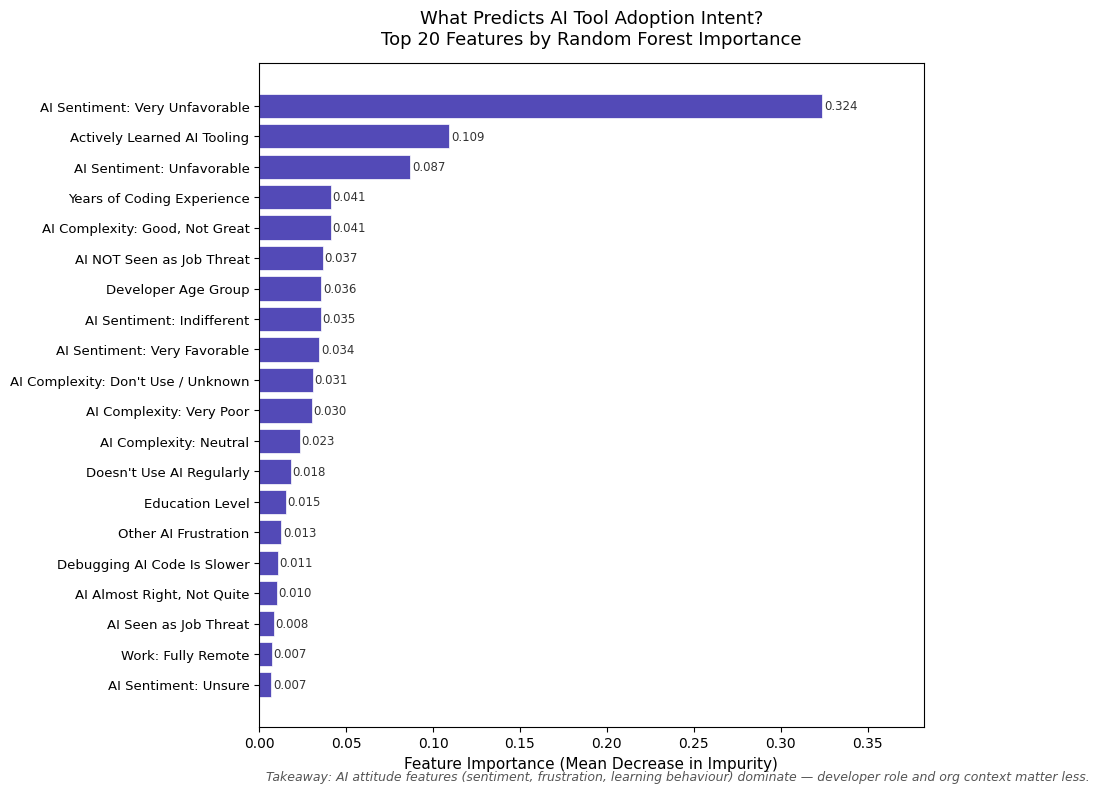

Chart saved to ..\outputs\figures\rf_feature_importance.png


In [4]:
# ── Top 20 feature importance chart ───────────────────────────────────────────
top20 = importance_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    y=top20['label'][::-1],          # reverse so highest importance is at top
    width=top20['importance'][::-1],
    color=GROUP_COLORS['intender'],   # purple — consistent with project color scheme
    edgecolor='white',
    linewidth=0.5,
)

# Annotate each bar with its importance score
for bar, val in zip(bars, top20['importance'][::-1]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', ha='left', fontsize=8.5, color='#333333'
    )

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title(
    'What Predicts AI Tool Adoption Intent?\nTop 20 Features by Random Forest Importance',
    fontsize=13, pad=14
)
ax.set_xlim(0, top20['importance'].max() * 1.18)
ax.tick_params(axis='y', labelsize=9.5)

# One-sentence takeaway
ax.annotate(
    'Takeaway: AI attitude features (sentiment, frustration, learning behaviour) '
    'dominate — developer role and org context matter less.',
    xy=(0.01, -0.08), xycoords='axes fraction',
    fontsize=9, color='#555555', style='italic'
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {FIGURES_DIR / "rf_feature_importance.png"}')

---
## Section 3 — Logistic Regression: Direction, Magnitude, and Odds Ratios

**Why Logistic Regression second?** Random Forest told us *which* features matter.
Logistic Regression tells us *in which direction* and *by how much* — the two
things a PM needs to turn a statistical finding into a product intervention.
Coefficients have sign (positive = associated with intender, negative = associated
with rejector) and magnitude (larger absolute value = stronger effect).
`exp(coefficient)` gives the odds ratio — a PM-friendly way to say "holding all
else equal, each unit increase in X multiplies the odds of being an intender by Y."

**Feature trimming:** Features with Random Forest importance < 0.01 are removed
before fitting. This gives Logistic Regression a clean, high-signal input set and
prevents coefficient instability from near-zero-variance features.

**VIF check:** After trimming, we run a Variance Inflation Factor check (threshold:
VIF > 5) to catch any residual multicollinearity. If flagged, we drop the feature
with lower RF importance, not the one with higher signal.

**Model settings:** `class_weight='balanced'` (required — 25/75 split), `lbfgs`
solver (handles multi-class logistic well, standard for this size dataset),
`max_iter=1000` (default 100 is too low for convergence on this feature set).

In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── Step 1: Trim to features with RF importance >= 0.01 ────────────────────────
IMPORTANCE_THRESHOLD = 0.01
trimmed_features = (
    importance_df[importance_df['importance'] >= IMPORTANCE_THRESHOLD]['feature']
    .tolist()
)

X_train_trimmed = X_train[trimmed_features]
X_test_trimmed  = X_test[trimmed_features]

print(f'Features after RF trimming (importance >= {IMPORTANCE_THRESHOLD}): '
      f'{len(trimmed_features)}')
print()

# ── Step 2: VIF check ──────────────────────────────────────────────────────────
# VIF measures how much the variance of a coefficient is inflated by correlation
# with other features. VIF > 5 signals problematic multicollinearity.
# We add a constant column because VIF is formally defined in that context.

X_vif = X_train_trimmed.copy().astype(float)
# Add constant so VIF is computed in a regression context
X_vif.insert(0, 'const', 1.0)

vif_values = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(1, X_vif.shape[1])  # skip the constant column (index 0)
]

vif_df = pd.DataFrame({
    'feature':    trimmed_features,
    'label':      [get_label(f) for f in trimmed_features],
    'rf_importance': [
        importance_df.loc[importance_df['feature'] == f, 'importance'].values[0]
        for f in trimmed_features
    ],
    'VIF': vif_values,
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print('VIF check (threshold: VIF > 5):')
print(f'  {"Feature":<45} {"VIF":>7}  {"RF Importance":>14}')
print(f'  {"-"*45} {"-"*7}  {"-"*14}')
for _, row in vif_df.iterrows():
    flag = '  *** EXCEEDS THRESHOLD' if row['VIF'] > 5 else ''
    print(f'  {row["label"]:<45} {row["VIF"]:>7.2f}  {row["rf_importance"]:>14.4f}{flag}')

flagged = vif_df[vif_df['VIF'] > 5]
print()
if flagged.empty:
    print('No features exceed VIF > 5. Proceeding with all 17 trimmed features.')
    lr_features = trimmed_features
else:
    # Drop the flagged feature with the LOWEST RF importance
    to_drop = flagged.sort_values('rf_importance').iloc[0]
    lr_features = [f for f in trimmed_features if f != to_drop['feature']]
    print(f'Dropping "{to_drop["label"]}" (VIF={to_drop["VIF"]:.2f}, '
          f'RF importance={to_drop["rf_importance"]:.4f} — lowest among flagged).')
    print(f'Features remaining for Logistic Regression: {len(lr_features)}')

X_train_lr = X_train[lr_features]
X_test_lr  = X_test[lr_features]

Features after RF trimming (importance >= 0.01): 17

VIF check (threshold: VIF > 5):
  Feature                                           VIF   RF Importance
  --------------------------------------------- -------  --------------
  AI Complexity: Don't Use / Unknown               2.96          0.0309
  Developer Age Group                              2.73          0.0358
  AI Sentiment: Very Unfavorable                   2.55          0.3239
  Years of Coding Experience                       2.53          0.0413
  AI Complexity: Very Poor                         2.52          0.0302
  AI Sentiment: Unfavorable                        2.06          0.0868
  AI Sentiment: Indifferent                        1.83          0.0355
  AI Complexity: Neutral                           1.47          0.0234
  AI Complexity: Good, Not Great                   1.38          0.0411
  Debugging AI Code Is Slower                      1.37          0.0107
  AI Almost Right, Not Quite                       

In [6]:
from sklearn.linear_model import LogisticRegression

# ── Fit Logistic Regression ────────────────────────────────────────────────────
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)
lr_model.fit(X_train_lr, y_train)

# ── AUC-ROC on test set ────────────────────────────────────────────────────────
lr_proba = lr_model.predict_proba(X_test_lr)[:, 1]
lr_auc   = roc_auc_score(y_test, lr_proba)
print(f'Logistic Regression — AUC-ROC (test set): {lr_auc:.4f}')
print()

# ── Odds ratio table ───────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'feature':    lr_features,
    'label':      [get_label(f) for f in lr_features],
    'coefficient': lr_model.coef_[0],
}).assign(odds_ratio=lambda d: np.exp(d['coefficient']))
coef_df['abs_coef'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('Odds ratio table (sorted by absolute coefficient):')
print(f'  {"Feature":<45} {"Coefficient":>12} {"Odds Ratio":>11}  {"Interpretation"}')
print(f'  {"-"*45} {"-"*12} {"-"*11}  {"-"*30}')
for _, row in coef_df.iterrows():
    direction = 'Intender' if row['coefficient'] > 0 else 'Rejector'
    print(f'  {row["label"]:<45} {row["coefficient"]:>12.3f} {row["odds_ratio"]:>11.3f}'
          f'  Associated with {direction}')

Logistic Regression — AUC-ROC (test set): 0.8537

Odds ratio table (sorted by absolute coefficient):
  Feature                                        Coefficient  Odds Ratio  Interpretation
  --------------------------------------------- ------------ -----------  ------------------------------
  AI Sentiment: Very Unfavorable                      -3.196       0.041  Associated with Rejector
  AI Sentiment: Unfavorable                           -1.685       0.186  Associated with Rejector
  AI Sentiment: Very Favorable                         1.176       3.242  Associated with Intender
  Actively Learned AI Tooling                          0.956       2.602  Associated with Intender
  AI Complexity: Good, Not Great                       0.712       2.037  Associated with Intender
  AI NOT Seen as Job Threat                           -0.654       0.520  Associated with Rejector
  AI Complexity: Very Poor                            -0.549       0.578  Associated with Rejector
  AI Complex

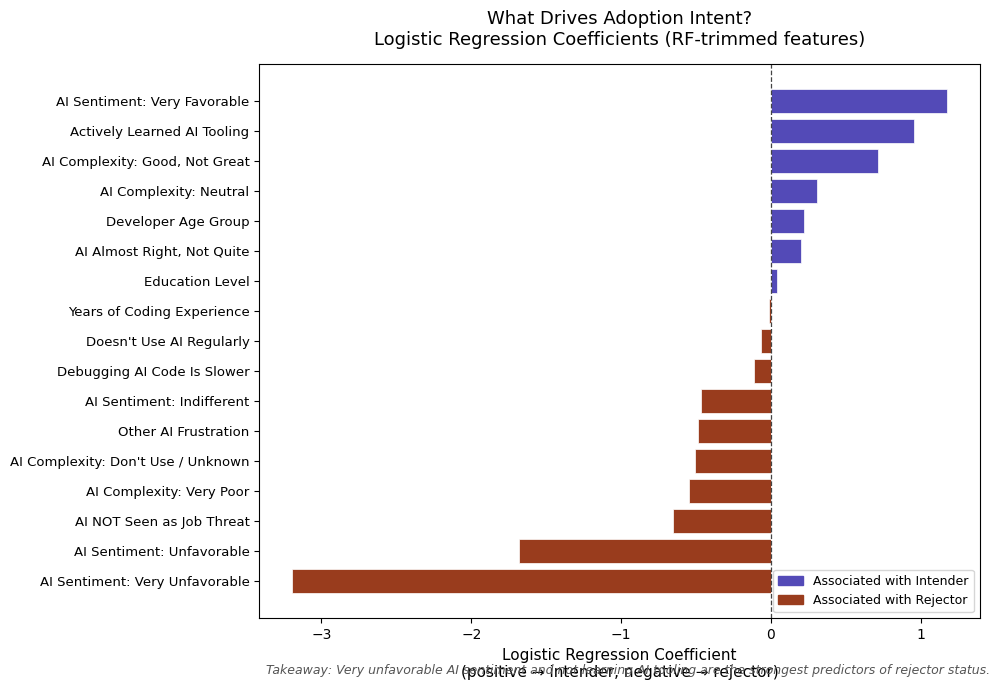

Chart saved to ..\outputs\figures\lr_coefficients.png


In [7]:
# ── Coefficient chart ──────────────────────────────────────────────────────────
# Sorted by coefficient value (most negative at bottom, most positive at top)
coef_plot = coef_df.sort_values('coefficient')

bar_colors = [
    GROUP_COLORS['intender'] if c > 0 else GROUP_COLORS['rejector']
    for c in coef_plot['coefficient']
]

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    y=coef_plot['label'],
    width=coef_plot['coefficient'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
)

ax.axvline(x=0, color='#444444', linewidth=0.9, linestyle='--')

ax.set_xlabel('Logistic Regression Coefficient\n(positive → intender, negative → rejector)',
              fontsize=11)
ax.set_title(
    'What Drives Adoption Intent?\nLogistic Regression Coefficients (RF-trimmed features)',
    fontsize=13, pad=14
)
ax.tick_params(axis='y', labelsize=9.5)

# Legend
intender_patch = mpatches.Patch(color=GROUP_COLORS['intender'], label='Associated with Intender')
rejector_patch = mpatches.Patch(color=GROUP_COLORS['rejector'], label='Associated with Rejector')
ax.legend(handles=[intender_patch, rejector_patch], loc='lower right', fontsize=9)

ax.annotate(
    'Takeaway: Very unfavorable AI sentiment and not learning AI tooling '
    'are the strongest predictors of rejector status.',
    xy=(0.01, -0.10), xycoords='axes fraction',
    fontsize=9, color='#555555', style='italic'
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {FIGURES_DIR / "lr_coefficients.png"}')

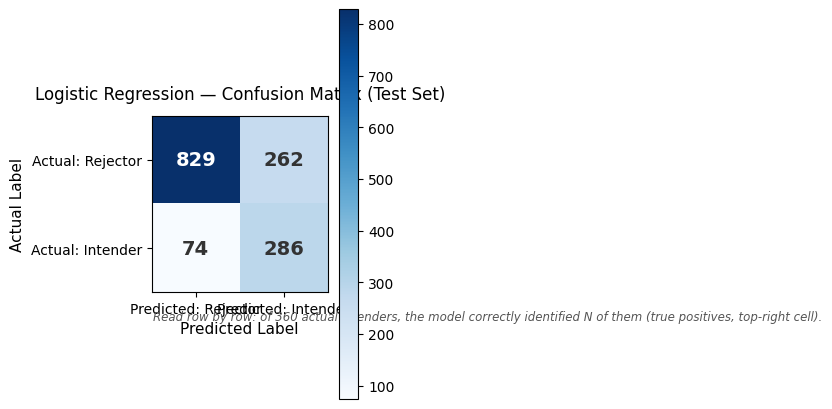

Chart saved to ..\outputs\figures\lr_confusion_matrix.png

Classification report:
              precision    recall  f1-score   support

    Rejector       0.92      0.76      0.83      1091
    Intender       0.52      0.79      0.63       360

    accuracy                           0.77      1451
   macro avg       0.72      0.78      0.73      1451
weighted avg       0.82      0.77      0.78      1451



In [8]:
from sklearn.metrics import confusion_matrix, classification_report

# ── Confusion matrix ───────────────────────────────────────────────────────────
y_pred_lr = lr_model.predict(X_test_lr)
cm        = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

# Annotate each cell with its count
for row in range(2):
    for col in range(2):
        color = 'white' if cm[row, col] > cm.max() / 2 else '#333333'
        ax.text(col, row, f'{cm[row, col]:,}',
                ha='center', va='center', fontsize=14,
                fontweight='bold', color=color)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Rejector', 'Predicted: Intender'], fontsize=10)
ax.set_yticklabels(['Actual: Rejector', 'Actual: Intender'], fontsize=10)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_title('Logistic Regression — Confusion Matrix (Test Set)', fontsize=12, pad=12)

ax.annotate(
    'Read row by row: of 360 actual intenders, the model correctly identified N '
    'of them (true positives, top-right cell).',
    xy=(0.01, -0.16), xycoords='axes fraction',
    fontsize=8.5, color='#555555', style='italic'
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'lr_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {FIGURES_DIR / "lr_confusion_matrix.png"}')
print()
print('Classification report:')
print(classification_report(y_test, y_pred_lr, target_names=['Rejector', 'Intender']))

---
## Section 4 — CART Decision Tree: Human-Readable Decision Rules

**Why CART last?** Random Forest gave us importance. Logistic Regression gave
us direction and magnitude. CART gives us something neither can: a decision
rule a PM can read without any statistical training.

**This is the communication layer**, not an additional modelling layer. CART
uses the same feature set as Logistic Regression. Its job is to surface the
most important splits in a form that translates directly to the product deck.

**Model settings:**
- max_depth=4 — no deeper than 4 splits; keeps the tree readable
- min_samples_leaf=50 — each leaf must represent at least 50 developers
- class_weight=balanced — consistent with the other two models

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# ── Fit CART ───────────────────────────────────────────────────────
# Uses lr_features (17 RF-trimmed features, VIF-validated) from Section 3
cart_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)
cart_model.fit(X_train_lr, y_train)

# ── AUC-ROC on test set ────────────────────────────────────────────
cart_proba = cart_model.predict_proba(X_test_lr)[:, 1]
cart_auc   = roc_auc_score(y_test, cart_proba)
print(f'CART Decision Tree — AUC-ROC (test set): {cart_auc:.4f}')
print(f'Tree depth used: {cart_model.get_depth()} (max allowed: 4)')
print(f'Number of leaves: {cart_model.get_n_leaves()}')

CART Decision Tree — AUC-ROC (test set): 0.8332
Tree depth used: 4 (max allowed: 4)
Number of leaves: 15


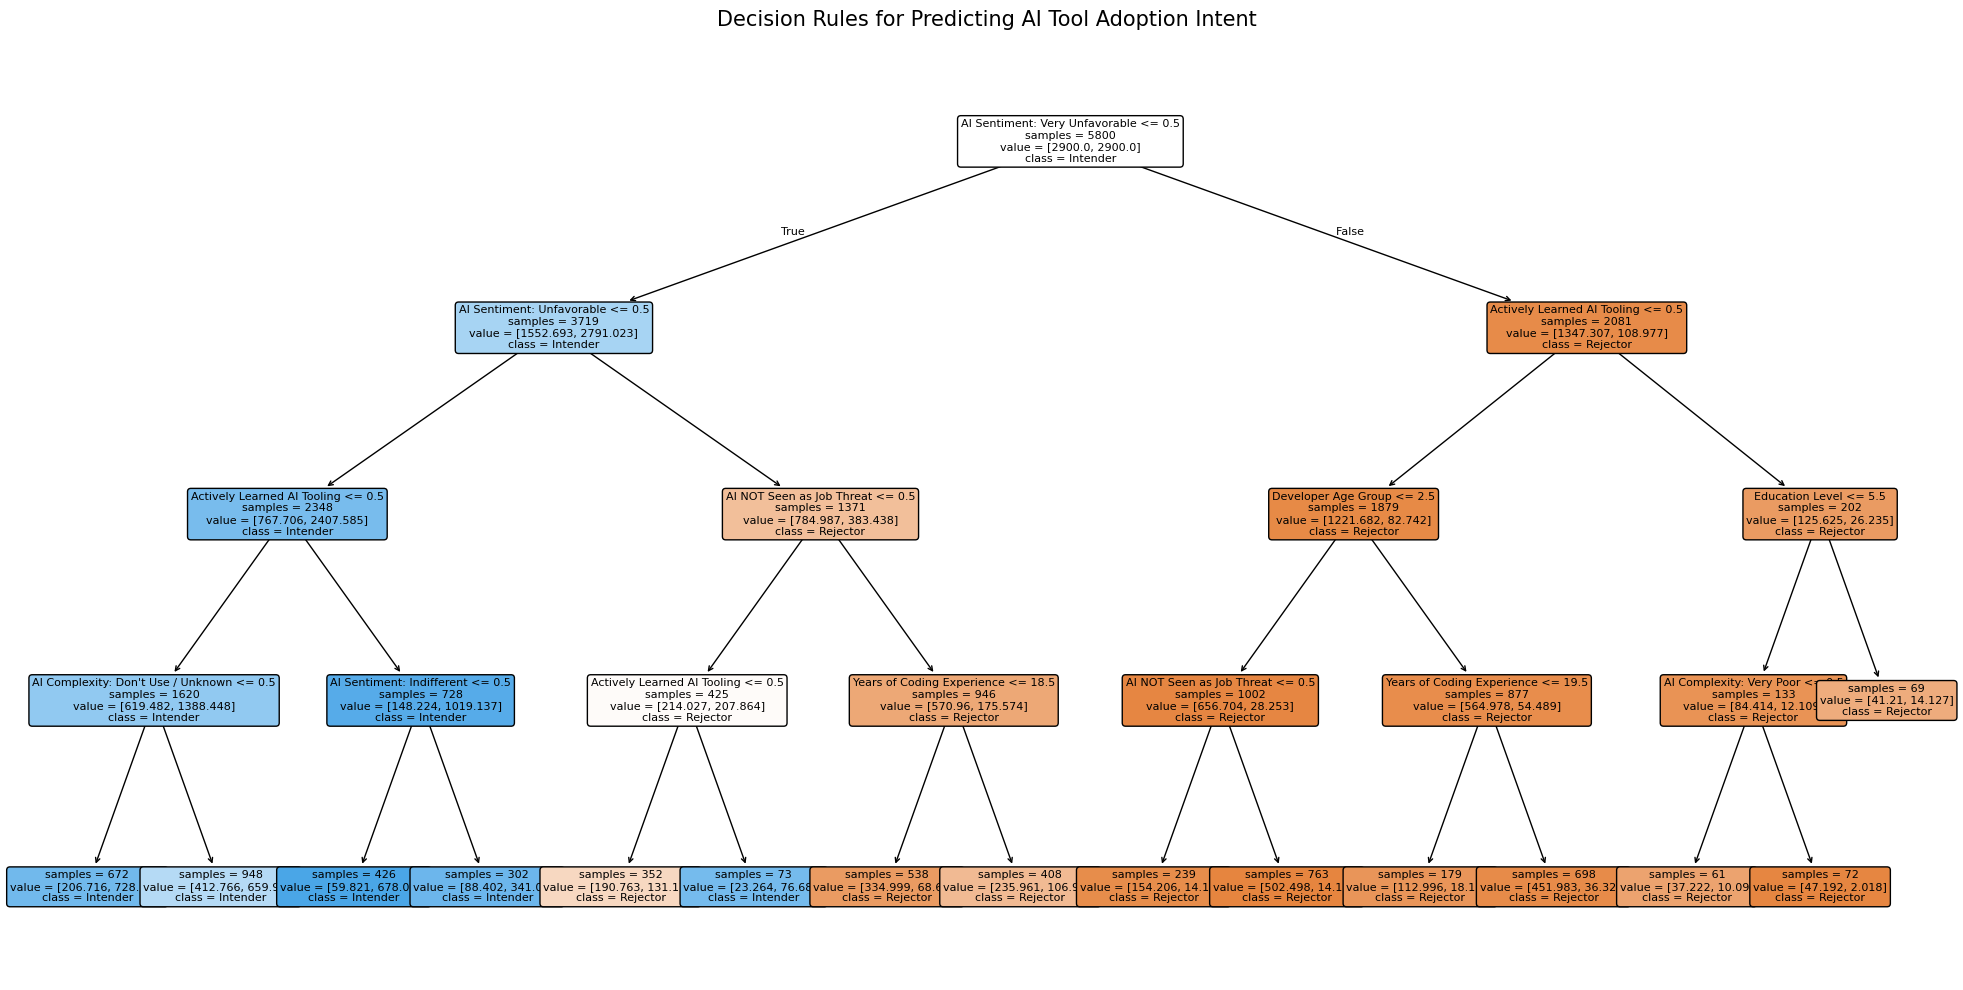

Chart saved to ..\outputs\figures\cart_decision_tree.png


In [10]:
# ── Decision tree visualization ───────────────────────────────────
# Business-friendly feature names on the tree nodes
cart_feature_labels = [get_label(f) for f in lr_features]

fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    cart_model,
    feature_names=cart_feature_labels,
    class_names=['Rejector', 'Intender'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=False,       # hide Gini score — not PM-relevant
    proportion=False,     # show raw counts, not proportions
)

ax.set_title(
    'Decision Rules for Predicting AI Tool Adoption Intent',
    fontsize=15, pad=16
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'cart_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {FIGURES_DIR / "cart_decision_tree.png"}')

In [11]:
from sklearn.tree import _tree

def extract_decision_paths(tree_clf, feat_names, label_map, class_names):
    """Walk every root-to-leaf path. Returns list of leaf dicts, sorted by n_samples."""
    tree_     = tree_clf.tree_
    feat_cols = [
        feat_names[i] if i != _tree.TREE_UNDEFINED else None
        for i in tree_.feature
    ]
    paths = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            feat   = feat_cols[node]
            thresh = tree_.threshold[node]
            label  = label_map.get(feat, feat)
            # Binary indicator: threshold is ~0.5
            if abs(thresh - 0.5) < 0.1:
                recurse(tree_.children_left[node],  conditions + ["NOT " + label])
                recurse(tree_.children_right[node], conditions + [label])
            else:
                recurse(tree_.children_left[node],  conditions + [label + " <= " + str(round(thresh, 1))])
                recurse(tree_.children_right[node], conditions + [label + " > "  + str(round(thresh, 1))])
        else:
            values    = tree_.value[node][0]
            n_samples = int(tree_.n_node_samples[node])
            total     = sum(values)
            probs     = [v / total for v in values]
            predicted = class_names[int(np.argmax(probs))]
            paths.append({
                "conditions":    conditions,
                "n_samples":     n_samples,
                "predicted":     predicted,
                "intender_prob": round(probs[1] * 100, 1),
                "rejector_prob": round(probs[0] * 100, 1),
            })

    recurse(0, [])
    paths.sort(key=lambda x: -x["n_samples"])
    return paths


paths = extract_decision_paths(cart_model, lr_features, FEATURE_LABEL_MAP,
                                ["Rejector", "Intender"])

print("Top 3 Decision Paths (by number of developers in leaf)")
print("=" * 65)
for i, p in enumerate(paths[:3], 1):
    print()
    print("Path " + str(i) + ":")
    for j, cond in enumerate(p["conditions"], 1):
        connector = "If" if j == 1 else "AND"
        print("  " + connector + " " + cond)
    print("  -> Predicted: " + p["predicted"])
    print("     Intender probability: " + str(p["intender_prob"]) + "%")
    print("     Rejector probability: " + str(p["rejector_prob"]) + "%")
    print("     Developers in this leaf: " + str(p["n_samples"]))

Top 3 Decision Paths (by number of developers in leaf)

Path 1:
  If NOT AI Sentiment: Very Unfavorable
  AND NOT AI Sentiment: Unfavorable
  AND NOT Actively Learned AI Tooling
  AND AI Complexity: Don't Use / Unknown
  -> Predicted: Intender
     Intender probability: 61.5%
     Rejector probability: 38.5%
     Developers in this leaf: 948

Path 2:
  If AI Sentiment: Very Unfavorable
  AND NOT Actively Learned AI Tooling
  AND Developer Age Group <= 2.5
  AND AI NOT Seen as Job Threat
  -> Predicted: Rejector
     Intender probability: 2.7%
     Rejector probability: 97.3%
     Developers in this leaf: 763

Path 3:
  If AI Sentiment: Very Unfavorable
  AND NOT Actively Learned AI Tooling
  AND Developer Age Group > 2.5
  AND Years of Coding Experience > 19.5
  -> Predicted: Rejector
     Intender probability: 7.4%
     Rejector probability: 92.6%
     Developers in this leaf: 698
